In [ ]:
# CELL 1: Imports and Load Dataset
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Test images shape     :", x_test.shape)
print("Test labels shape     :", y_test.shape)
print("Pixel value range     :", x_train.min(), "–", x_train.max())
print("Classes               :", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Test labels shape     : (10000, 1)
Pixel value range     : 0 – 255
Classes               : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# MEMBER 5:
# CELL 13: Pixel value statistics per color channel
channel_names = ['Red', 'Green', 'Blue']

for i, ch in enumerate(channel_names):
    mean_val = x_train[:, :, :, i].mean()
    std_val = x_train[:, :, :, i].std()
    print(f"{ch} channel -> mean: {mean_val:.2f}, std: {std_val:.2f}")

Red channel -> mean: 125.31, std: 62.99
Green channel -> mean: 122.95, std: 62.09
Blue channel -> mean: 113.87, std: 66.70


In [ ]:
# CELL 14:
# Normalization / Scaling
# Step 1: Check current pixel value range (0-255 is too large for a neural network)
print("Pixel range before normalization:", x_train.min(), "to", x_train.max())

# Step 2: Scale pixel values down to the range 0-1
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("Pixel range after normalization:", x_train_norm.min(), "to", x_train_norm.max())

Pixel range before normalization: 0 to 255
Pixel range after normalization: 0.0 to 1.0


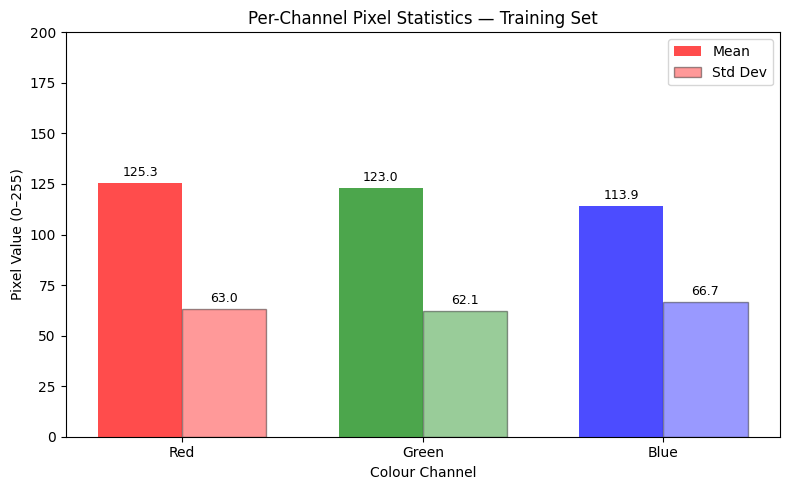

In [ ]:
# CELL 15: Pixel statistics bar chart — mean and std per colour channel
import matplotlib.pyplot as plt
import numpy as np

channel_names = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

means = [x_train[:,:,:,i].mean() for i in range(3)]
stds  = [x_train[:,:,:,i].std()  for i in range(3)]

x = np.arange(len(channel_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, means, width, label='Mean', color=colors, alpha=0.7)
bars2 = ax.bar(x + width/2, stds,  width, label='Std Dev', color=colors, alpha=0.4, edgecolor='black')

ax.set_xlabel('Colour Channel')
ax.set_ylabel('Pixel Value (0–255)')
ax.set_title('Per-Channel Pixel Statistics — Training Set')
ax.set_xticks(x)
ax.set_xticklabels(channel_names)
ax.legend()
ax.set_ylim(0, 200)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()